# Denoising Autoencoder para CIFAR10 

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, MaxPool2D, Conv2DTranspose
from tensorflow.keras.models import Model

## Datos

In [2]:
(x_train, _), (x_test, _) = cifar10.load_data()

#normalizacion
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train.shape,x_test.shape

/Users/octavioperezurbina/Documents/iteso/deep-learning/course-2026/.venv/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


((50000, 32, 32, 3), (10000, 32, 32, 3))

In [3]:
# ruido gausiano
def add_noise(x, noise_factor):
    x_noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    return np.clip(x_noisy, 0.0, 1.0)

## Modelado

In [9]:
encoding_dim = 32

input_img = Input(shape=(32, 32, 3))

# (32,32,3) -> (32,32,16)
encoder = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
# (32,32,16) -> (16,16,16)
encoder = MaxPool2D((2, 2))(encoder)
# (16,16,16) -> (4096,)
encoder = Flatten()(encoder)
# (4096,) -> (32,)
z = Dense(encoding_dim, activation='relu')(encoder)

# (32,) -> (4096,)
decoder = Dense(16 * 16 * 16, activation='relu')(z)
# (4096,) -> (16,16,16)
decoder = Reshape((16, 16, 16))(decoder)
# (16,16,16) -> (32,32,3)
decoded = Conv2DTranspose(3, (2, 2), strides=(2, 2), padding='same', activation='sigmoid')(decoder)

autoencoder = Model(input_img, decoded)
encoder_model = Model(input_img, z)


z_input = Input(shape=(encoding_dim,))
decode_layer1 = autoencoder.layers[-3]
decode_layer2 = autoencoder.layers[-2]
decode_layer3 = autoencoder.layers[-1]
decoder_model = Model(
                    z_input
                    , decode_layer3(decode_layer2(decode_layer1(z_input))))

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       135,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 3)      │           195 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,915 (1.02 MB)

 Trainable params: 266,915 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
noise_factor = 0.2
x_train_noisy = add_noise(x_train, noise_factor)
x_test_noisy = add_noise(x_test, noise_factor)


## MSE

In [17]:
autoencoder.compile(optimizer='adam', loss='mse')


history_mse = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0259 - val_loss: 0.0204
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0203 - val_loss: 0.0200
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0200 - val_loss: 0.0198
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0199 - val_loss: 0.0197
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0198 - val_loss: 0.0196
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0197 - val_loss: 0.0195
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0196 - val_loss: 0.0195
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0195 - val_loss: 0.0193
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0194 - val_loss: 0.0193
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0193 - val_loss: 0.0192
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0193 - val_loss: 0.0192
Epoch 12/15
1250/1250 ━━━━━━━━

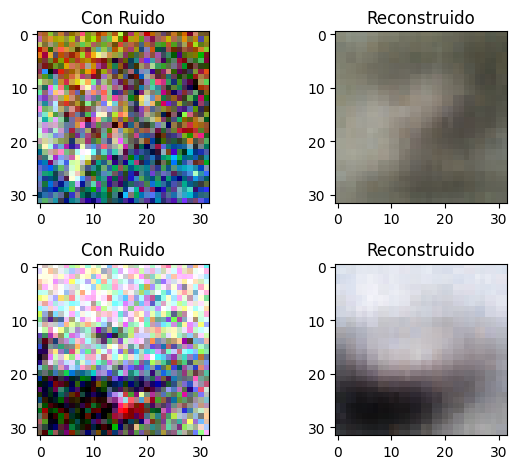

In [32]:
fig, axes = plt.subplots(2,2)


axes[0,0].set_title('Con Ruido')
axes[0,0].imshow(x_test_noisy[0])

axes[0,1].imshow(pred[0])
axes[0,1].set_title('Reconstruido')

axes[1,0].set_title('Con Ruido')
axes[1,0].imshow(x_test_noisy[1])

axes[1,1].imshow(pred[1])
axes[1,1].set_title('Reconstruido')

plt.tight_layout()
plt.show()


## Binary Cross-Entropy

In [10]:
input_img_bce = Input(shape=(32, 32, 3))

# (32,32,3) -> (32,32,16)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img_bce)
# (32,32,16) -> (16,16,16)
x = MaxPool2D((2, 2))(x)
# (16,16,16) -> (4096,)
x = Flatten()(x)

# (4096,) -> (32,) bottleneck
z_bce = Dense(encoding_dim, activation='relu')(x)
# (32,) -> (4096,)
d = Dense(16 * 16 * 16, activation='relu')(z_bce)
# (4096,) -> (16,16,16)
d = Reshape((16, 16, 16))(d)
# (16,16,16) -> (32,32,3)

decoded = Conv2DTranspose(3, (2, 2), strides=(2, 2), padding='same', activation='sigmoid')(d)
autoencoder_bce = Model(input_img_bce, decoded)
autoencoder_bce.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_bce.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │       135,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 3)      │           195 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,915 (1.02 MB)

 Trainable params: 266,915 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_bce = autoencoder_bce.fit(
    x_train_noisy, x_train,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6064 - val_loss: 0.5939
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5925 - val_loss: 0.5928
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5909 - val_loss: 0.5918
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5904 - val_loss: 0.5910
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5900 - val_loss: 0.5907
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5896 - val_loss: 0.5904
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5893 - val_loss: 0.5902
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5892 - val_loss: 0.5901
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5890 - val_loss: 0.5900
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5888 - val_loss: 0.5897
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5886 - val_loss: 0.5895
Epoch 12/15
1250/1250 ━━━━━━━━

In [14]:
pred = autoencoder_bce.predict(x_test_noisy[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


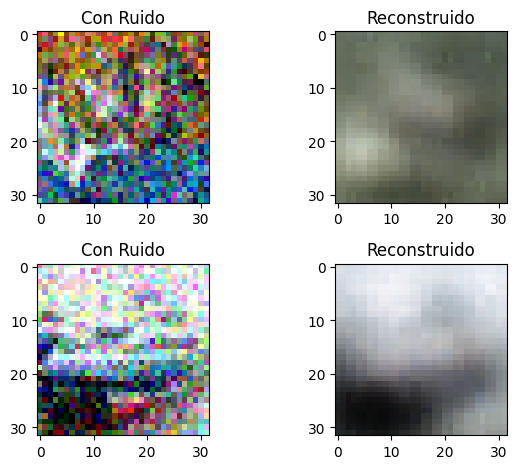

In [15]:
fig, axes = plt.subplots(2,2)


axes[0,0].set_title('Con Ruido')
axes[0,0].imshow(x_test_noisy[0])

axes[0,1].imshow(pred[0])
axes[0,1].set_title('Reconstruido')

axes[1,0].set_title('Con Ruido')
axes[1,0].imshow(x_test_noisy[1])

axes[1,1].imshow(pred[1])
axes[1,1].set_title('Reconstruido')

plt.tight_layout()
plt.show()



## Comparación MSE vs BCE

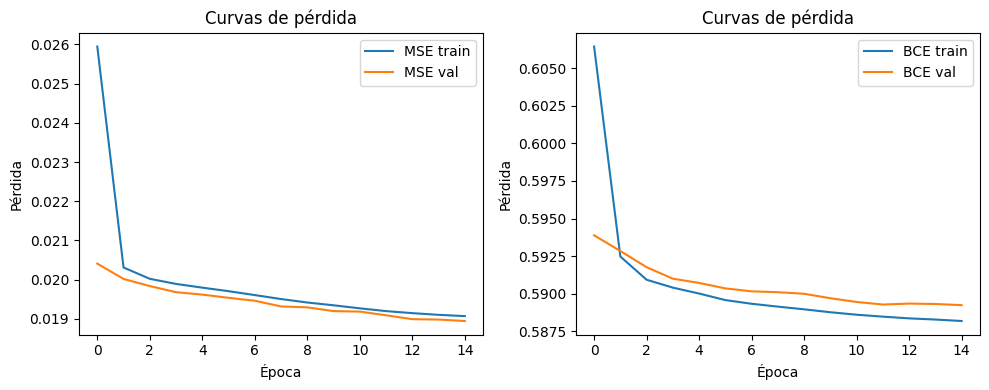

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_mse.history['loss'], label='MSE train')
axes[0].plot(history_mse.history['val_loss'], label='MSE val')

axes[1].plot(history_bce.history['loss'], label='BCE train')
axes[1].plot(history_bce.history['val_loss'], label='BCE val')

axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[0].set_title('Curvas de pérdida')

axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida')
axes[1].legend()
axes[1].set_title('Curvas de pérdida')

plt.tight_layout()
plt.show()

## Ruidos 0.2, 0.5, 0.8

In [34]:
# ruido 0.2
noise = 0.2
x_train_noisy = add_noise(x_train, noise)
x_test_noisy = add_noise(x_test, noise)

input_img = Input(shape=(32, 32, 3))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPool2D((2, 2))(x)
x = Flatten()(x)
z = Dense(encoding_dim, activation='relu')(x)
d = Dense(16 * 16 * 16, activation='relu')(z)
d = Reshape((16, 16, 16))(d)
decoded = Conv2DTranspose(3, (2, 2), strides=(2, 2), padding='same', activation='sigmoid')(d)
autoencoder_bce_02 = Model(input_img, decoded)
autoencoder_bce_02.compile(optimizer='adam', loss='binary_crossentropy')
history_bce_02 = autoencoder_bce_02.fit(x_train_noisy, x_train, epochs=8, validation_split=0.2)

Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6107 - val_loss: 0.5968
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.5945 - val_loss: 0.5941
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.5926 - val_loss: 0.5933
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5921 - val_loss: 0.5928
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.5916 - val_loss: 0.5927
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.5913 - val_loss: 0.5922
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.5910 - val_loss: 0.5920
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5909 - val_loss: 0.5920


In [35]:
# ruido 0.5
noise = 0.5
x_train_noisy = add_noise(x_train, noise)
x_test_noisy = add_noise(x_test, noise)

input_img = Input(shape=(32, 32, 3))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPool2D((2, 2))(x)
x = Flatten()(x)
z = Dense(encoding_dim, activation='relu')(x)
d = Dense(16 * 16 * 16, activation='relu')(z)
d = Reshape((16, 16, 16))(d)
decoded = Conv2DTranspose(3, (2, 2), strides=(2, 2), padding='same', activation='sigmoid')(d)
autoencoder_bce_05 = Model(input_img, decoded)
autoencoder_bce_05.compile(optimizer='adam', loss='binary_crossentropy')
history_bce_05 = autoencoder_bce_05.fit(x_train_noisy, x_train, epochs=8, validation_split=0.2)

Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.6242 - val_loss: 0.6139
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6102 - val_loss: 0.6097
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6085 - val_loss: 0.6088
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6080 - val_loss: 0.6084
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6077 - val_loss: 0.6082
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6075 - val_loss: 0.6082
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6073 - val_loss: 0.6079
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.6072 - val_loss: 0.6078


In [36]:
# ruido 0.8
noise = 0.8
x_train_noisy = add_noise(x_train, noise)
x_test_noisy = add_noise(x_test, noise)

input_img = Input(shape=(32, 32, 3))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPool2D((2, 2))(x)
x = Flatten()(x)
z = Dense(encoding_dim, activation='relu')(x)
d = Dense(16 * 16 * 16, activation='relu')(z)
d = Reshape((16, 16, 16))(d)
decoded = Conv2DTranspose(3, (2, 2), strides=(2, 2), padding='same', activation='sigmoid')(d)
autoencoder_bce_08 = Model(input_img, decoded)
autoencoder_bce_08.compile(optimizer='adam', loss='binary_crossentropy')
history_bce_08 = autoencoder_bce_08.fit(x_train_noisy, x_train, epochs=8, validation_split=0.2)

Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6350 - val_loss: 0.6229
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6209 - val_loss: 0.6190
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6179 - val_loss: 0.6184
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6149 - val_loss: 0.6153
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6136 - val_loss: 0.6147
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6133 - val_loss: 0.6140
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6131 - val_loss: 0.6139
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.6130 - val_loss: 0.6141


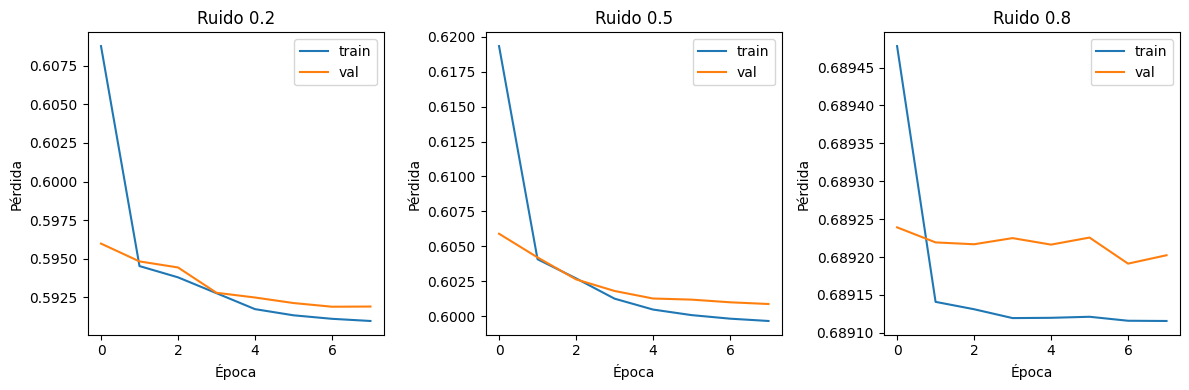

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (noise, hist) in zip(axes, [(0.2, history_bce_02), (0.5, history_bce_05), (0.8, history_bce_08)]):
    ax.plot(hist.history['loss'], label='train')
    ax.plot(hist.history['val_loss'], label='val')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida')
    ax.legend()
    ax.set_title(f'Ruido {noise}')
plt.tight_layout()
plt.show()

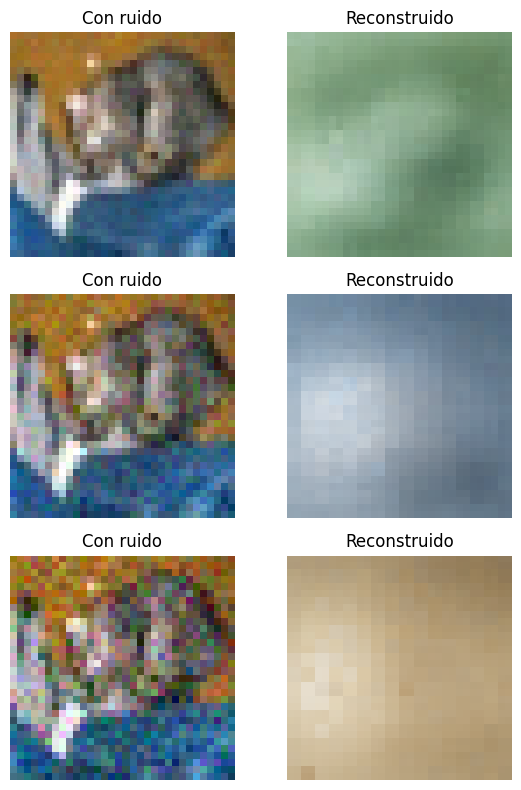

In [37]:
x_test_noisy_02 = add_noise(x_test, .02)
x_test_noisy_05 = add_noise(x_test, .05)
x_test_noisy_08 = add_noise(x_test, .08)

pred_02 = autoencoder_bce_02.predict(x_test_noisy_02[0:1], verbose=0)[0]
pred_05 = autoencoder_bce_05.predict(x_test_noisy_05[0:1], verbose=0)[0]
pred_08 = autoencoder_bce_08.predict(x_test_noisy_08[0:1], verbose=0)[0]

fig, axes = plt.subplots(3, 2, figsize=(6, 8))

axes[0, 0].set_title('Con ruido')
axes[0, 0].imshow(x_test_noisy_02[0])
axes[0, 0].set_ylabel('Ruido 0.2')
axes[0, 0].axis('off')

axes[0, 1].imshow(pred_02)
axes[0, 1].set_title('Reconstruido')
axes[0, 1].axis('off')

axes[1, 0].set_title('Con ruido')
axes[1, 0].imshow(x_test_noisy_05[0])
axes[1, 0].set_ylabel('Ruido 0.5')
axes[1, 0].axis('off')

axes[1, 1].imshow(pred_05)
axes[1, 1].set_title('Reconstruido')
axes[1, 1].axis('off')

axes[2, 0].set_title('Con ruido')
axes[2, 0].imshow(x_test_noisy_08[0])
axes[2, 0].set_ylabel('Ruido 0.8')
axes[2, 0].axis('off')

axes[2, 1].imshow(pred_08)
axes[2, 1].set_title('Reconstruido')
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()